In [143]:
# Import necessary modules
from get_lat_lon import get_lat_lon
import pandas as pd
import torch 
import numpy as np

# Load geographical coordinates and spatial data
lats = np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lats.npy")
lons = np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lons.npy")
sa_xcell = np.load("/User/homes/fhuang/lac_cnn/sa_x_cell.npy")

# Load and apply NaN index to remove invalid data points
nan_idx = np.load('/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/conv3d_res/nan_idx.npy')
sa_xcell = np.delete(sa_xcell, nan_idx, axis=0)

# Load input features (x), target variables (y2), and soil moisture data (y)
x = np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/xc_21.npy")
y2 = np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/y2c_21.npy")

# Load and process soil moisture data, removing NaN values
y = np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/smc_somo.npy')[:, :, -1]
nanindex = np.where(np.isnan(y[:, 205]))
x = np.delete(x, nanindex, axis=0)
y = np.delete(y, nanindex, axis=0)
y2 = np.delete(y2, nanindex, axis=0)
lats = np.delete(lats, nanindex, axis=0)
lons = np.delete(lons, nanindex, axis=0)
sa_xcell = np.delete(sa_xcell, nanindex, axis=0)

# Load gradient/explanation data from trained model
eg = np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/570/eg_30.npy")

# Create coordinate grids for spatial processing (21x21 grid centered at origin)
xx = np.linspace(-15, 15, 21)
yy = np.linspace(15, -15, 21)
xi, yi = np.meshgrid(xx, yy)

# Process each grid cell individually
for i in range(x.shape[0]):
    # Get center coordinates for the current grid cell
    x_cell = sa_xcell[i]
    lat_center, lon_center = get_lat_lon(x_cell)
    
    # Create geographical coordinate grids centered on current cell
    xlats = xi + lon_center
    ylons = yi + lat_center
    
    df_list = []
    # Process each month (time step) for the current grid cell
    for k in range(216):
        # Create land mask based on NaN values in input feature channel 9
        mask_land = np.isnan(x[i, k, :, :, 9])
        # Apply land mask to gradient data
        eg_land_masked = eg[i, 0, k, :, :] * (1 - mask_land)
    
        # Create upwind mask based on y2 values (threshold < 0.0001)
        y2i = y2[i, 0, k, :, :]
        y2i[y2i < 0.0001] = np.nan
        mask_upwind = y2i
        # Apply both land and upwind masks to gradient data
        eg_land_upwind_masked = (1 - mask_upwind) * eg_land_masked

        # Create DataFrame with processed gradient data and metadata
        df = pd.DataFrame({
            "x_cell": [i] * 21 * 21,  # Grid cell identifier
            "month": [k] * 21 * 21,   # Month identifier
            "xlats": xlats.reshape(-1, 1)[:, 0],  # Longitude coordinates
            "ylons": ylons.reshape(-1, 1)[:, 0],  # Latitude coordinates
            "eg_upwind": eg_land_upwind_masked.reshape(-1, 1)[:, 0],  # Upwind-masked gradients
            "eg_total": eg_land_masked.reshape(-1, 1)[:, 0]  # Land-masked gradients
        })
        df_list.append(df)
    
    # Combine all monthly data for current grid cell and save to CSV
    df_i = pd.concat(df_list, axis=0, ignore_index=True)
    df_i.to_csv("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/570/eg_overlap_noeval/" + str(i) + ".csv")

In [147]:
import pandas as pd
from get_lat_lon import get_lat_lon
import numpy as np

# Load geographical coordinates and spatial data
lats = np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lats.npy")
lons = np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lons.npy")
sa_xcell = np.load("/User/homes/fhuang/lac_cnn/sa_x_cell.npy")

# Load and apply NaN index to remove invalid data points
nan_idx = np.load('/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/conv3d_res/nan_idx.npy')
sa_xcell = np.delete(sa_xcell, nan_idx, axis=0)

# Load and process soil moisture data to remove NaN values
y = np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/smc_somo.npy')[:, :, -1]
nanindex = np.where(np.isnan(y[:, 205]))
lats = np.delete(lats, nanindex, axis=0)
lons = np.delete(lons, nanindex, axis=0)
sa_xcell = np.delete(sa_xcell, nanindex, axis=0)

# Initialize list to store processed data from all grid cells
vl = []
# Read and concatenate CSV files for all 733 grid cells
for i in range(733):
    v = pd.read_csv("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/" + str('570') + "/eg_overlap_noeval/" + str(i) + ".csv", index_col=0)
    vl.append(v)
# Combine all individual grid cell data into a single DataFrame
df = pd.concat(vl, axis=0)

# Initialize arrays to store aggregated gradient values
eg_overlap_upwind = np.full((733, 216, 1), np.nan)  # For upwind-masked gradients
eg_overlap_total = np.full((733, 216, 1), np.nan)   # For total land-masked gradients

# Process each grid cell to aggregate gradient values
for i in range(733):
    # Get center coordinates for the current grid cell
    x_cell = sa_xcell[i]
    lat_center, lon_center = get_lat_lon(x_cell)
    
    # Filter data for the center point of the current grid cell
    vx = df[(df["xlats"] == lon_center) & (df["ylons"] == lat_center)]
    
    # Aggregate gradient values by month (sum across spatial dimensions)
    eg_overlap_upwind[i, :, 0] = vx.groupby("month").sum()["eg_upwind"]
    eg_overlap_total[i, :, 0] = vx.groupby("month").sum()["eg_total"]

# Save the aggregated gradient arrays for further analysis
np.save("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/" + str('570') + "/eg_upwind_overlap_noeval.npy", eg_overlap_upwind)
np.save("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/" + str('570') + "/eg_total_overlap_noeval.npy", eg_overlap_total)

In [148]:
########## Mask Wind Data ################
import xarray as xr

# Load wind component data (u10: east-west, v10: north-south)
u10 = xr.open_dataarray("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/u10.nc")
v10 = xr.open_dataarray("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/v10.nc")

# Load land mask data (1=land, 0=ocean or NaN=invalid)
mask = xr.open_dataarray(('/Net/Groups/BGI/scratch/fhuang/utrack/uta_res/mask.nc'))

# Initialize arrays for masked wind data (18 time steps, 12 months, 107x240 grid)
u10m = np.full((18, 12, 107, 240), np.nan)
v10m = np.full((18, 12, 107, 240), np.nan)

# Apply land mask to wind data for each time step and month
for i in range(18):  # Loop through 18 time steps (e.g., years)
    for j in range(12):  # Loop through 12 months
        # Apply mask: multiply wind data by mask (0 for ocean, 1 for land)
        u10m[i, j, :, :] = u10[i, j].data * mask
        v10m[i, j, :, :] = v10[i, j].data * mask

# Create new xarray DataArrays with masked wind data and preserved metadata
u10mm = xr.DataArray(u10m, 
                    dims=("time", "month", "latitude", "longitude"),  
                    coords={"time": u10.time, "month": u10.month,
                            "latitude": u10.latitude, "longitude": u10.longitude})

v10mm = xr.DataArray(v10m, 
                    dims=("time", "month", "latitude", "longitude"),  
                    coords={"time": v10.time, "month": v10.month,
                            "latitude": v10.latitude, "longitude": v10.longitude})

In [149]:
# Load the upwind gradient overlap data from numpy file
eg_overlap_upwind = np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/570/eg_upwind_overlap_noeval.npy")

# Check the shape/dimensions of the loaded array
eg_overlap_upwind.shape

(733, 216, 1)

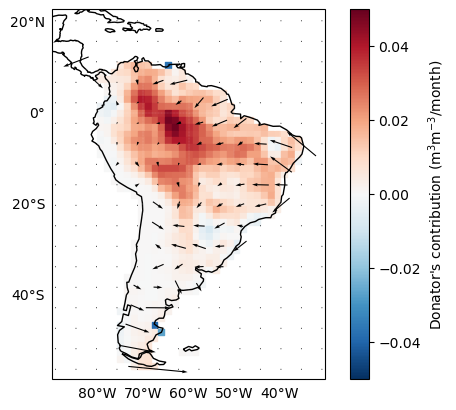

In [153]:
# Import visualization and mapping libraries
from matplotlib.colors import CenteredNorm, Normalize, TwoSlopeNorm
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xarray as xr

# Load geographical coordinates and process to remove NaN values
lats = np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lats.npy")
lons = np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lons.npy")
y = np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/smc_somo.npy')[:, :, -1]
nanindex = np.where(np.isnan(y[:, 205]))
lats = np.delete(lats, nanindex, axis=0)
lons = np.delete(lons, nanindex, axis=0)

# Load and average multiple gradient datasets for robustness
eg_overlap_upwind0 = np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/570/eg_upwind_overlap_noeval.npy")
eg_overlap_upwind1 = np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567/eg_upwind_overlap.npy")
eg_overlap_upwind2 = np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/568/eg_upwind_overlap.npy")
eg_overlap_upwind3 = np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/569/eg_upwind_overlap.npy")
eg_overlap_upwind = (eg_overlap_upwind0 + eg_overlap_upwind1 + eg_overlap_upwind2 + eg_overlap_upwind3) / 4

# Set diverging colormap normalization centered at zero
norm = TwoSlopeNorm(vmin=-0.05, vcenter=0., vmax=0.05)

# Create geographical plot with PlateCarree projection
fig, axis = plt.subplots(1, 1, subplot_kw=dict(projection=ccrs.PlateCarree()))
axis.coastlines()  # Add coastline boundaries
gl = axis.gridlines(draw_labels=True, linewidth=0.2, color='white', alpha=0.5, linestyle='--')
gl.top_labels = False                                 
gl.right_labels = False

# Create scatter plot showing average gradient contributions (donor influence)
sc = plt.scatter(lons[:], lats[:], s=18, 
                c=np.nanmean(eg_overlap_upwind[:, :, 0], axis=1), 
                norm=norm, cmap='RdBu_r', marker="s")
plt.colorbar(sc, label="Donator's contribution (m$^3$m$^{-3}$/month)")

# Add wind vector quiver plot showing mean wind patterns
cb = axis.quiver(u10mm.mean(dim=["time", "month"])[::3, ::3].longitude,
                u10mm.mean(dim=["time", "month"])[::3, ::3].latitude,
                u10mm.mean(dim=["time", "month"])[::3, ::3],
                v10mm.mean(dim=["time", "month"])[::3, ::3],
                pivot='mid', scale=30, width=0.004,
                transform=ccrs.PlateCarree(), color='k', angles='xy', zorder=1)

# Set map extent to focus on South America
axis.set_extent([-90, -30, -55, 20])